In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
import numpy as np
from tqdm import tqdm


In [5]:
class CombinedImageClassifier(nn.Module):
    def __init__(self, num_classes):
        super(CombinedImageClassifier, self).__init__()
        self.conv1 = nn.Conv2d(6, 32, kernel_size=3, padding=1)  # Input channels = 6 (RGB + RGB mask)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Adaptive average pooling to handle varying feature map sizes
        self.avgpool = nn.AdaptiveAvgPool2d((8, 8)) #adjust these numbers as needed

        self.fc1 = nn.Linear(128 * 8 * 8, 512)  # Adjust the input size accordingly
        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)



    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))

        x = self.avgpool(x)
        x = torch.flatten(x, 1)  # Flatten the feature map
        x = self.dropout(self.relu4(self.fc1(x)))
        x = self.fc2(x)
        return x



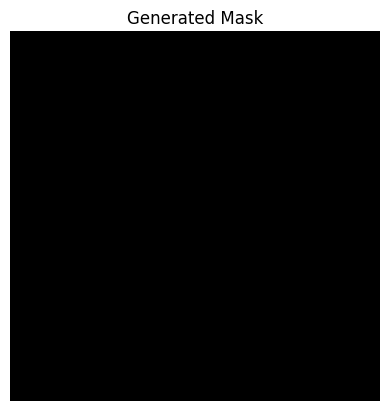

AttributeError: 'numpy.ndarray' object has no attribute 'detach'

In [9]:
import torch
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from UNET.model import build_unet
from UNET.utils import create_dir, seeding

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths to models
MASK_GENERATOR_PATH = 'files/checkpoint.pth'
DISEASE_PREDICTOR_PATH = 'pytorch_model.pth'

# Load models
mask_generator = torch.load(MASK_GENERATOR_PATH, map_location=device)
disease_predictor = torch.load(DISEASE_PREDICTOR_PATH, map_location=device)

# Set models to evaluation mode

model = build_unet()
model = model.to(device)
model.load_state_dict(mask_generator)
model.eval()


classifier = CombinedImageClassifier(num_classes=4).to(device)
classifier.load_state_dict(disease_predictor)
classifier.eval()


IMG_WIDTH = 512
IMG_HEIGHT = 512

# Preprocessing functions
def preprocess_image(image_path, img_width=IMG_WIDTH, img_height=IMG_HEIGHT):
    """
    Load, resize, and normalize the input image.
    """
    image = Image.open(image_path).convert('RGB')
    image = image.resize((img_width, img_height))
    image = np.array(image) / 255.0  # Normalize
    image = torch.tensor(image.transpose(2, 0, 1), dtype=torch.float32).unsqueeze(0)  # Add batch dimension
    return image


def postprocess_mask(mask_tensor):
    """
    Postprocess the predicted mask to a usable image.
    """
    # mask = mask_tensor.squeeze().detach().cpu().numpy()
    # mask = (mask > 0.5).astype(np.uint8) * 255  # Binary mask
    return mask_tensor*255


def apply_mask(image_tensor, mask_tensor):
    """
    Apply the mask to the original image.
    """
    mask = mask_tensor.squeeze().detach().cpu().numpy()
    binary_mask = (mask > 0.5).astype(np.float32)
    image = image_tensor.squeeze().detach().cpu().numpy().transpose(1, 2, 0)
    masked_image = image * binary_mask[..., np.newaxis]
    return masked_image


# Load and preprocess input image
image_path = '09_g.png'  # Update with the actual path
input_image = preprocess_image(image_path).to(device)

# Generate mask from the first model
with torch.no_grad():
    pred_y = model(input_image)
    pred_y = torch.sigmoid(pred_y)
    pred_y = pred_y[0].cpu().numpy()
    pred_y = np.squeeze(pred_y, axis=0)       # (512, 512)
    pred_y = pred_y > 0.5
    pred_y = np.array(pred_y, dtype=np.uint8)

# Postprocess and visualize the generated mask
mask_image = postprocess_mask(pred_y)
plt.imshow(mask_image, cmap='gray')
plt.title("Generated Mask")
plt.axis('off')
plt.show()

# Apply mask to the input image
masked_image = apply_mask(input_image, pred_y)
plt.imshow(masked_image)
plt.title("Masked Image")
plt.axis('off')
plt.show()

# Prepare input for the second model
masked_input = torch.tensor(masked_image.transpose(2, 0, 1), dtype=torch.float32).unsqueeze(0).to(device)

# Predict disease
with torch.no_grad():
    prediction = classifier(torch.cat((input_image, masked_input), dim=1))  # Concatenate original + masked

# Display prediction
predicted_class = torch.argmax(prediction, dim=1).item()
print(f"Predicted Disease Class: {predicted_class}")
